# Intro

This notebook builds a minimal synthetic vision task: classifying a single line as horizontal (0) or vertical (1) using a CNN trained with

$$
\text{BCEWithLogitsLoss}
$$

Images are generated programmatically (30×30, one line passing through the center) and rotated across a range of angles. This gives full control over geometry and labels.

The model outputs a single logit

$$
z \in \mathbb{R}
$$

which is converted to a probability

$$
p(\text{vertical}) = \sigma(z)
$$

Instead of focusing on accuracy, we analyze the learned decision function

$$
p(\text{vertical} \mid \text{angle})
$$

by plotting it against the line angle. This shows how the network transitions from horizontal to vertical perception and reveals its geometric inductive bias.

The goal is interpretability and system understanding, not benchmarks.


# Imports

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torchsummary import summary

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# Data

In [2]:
n_gauss = 1000
img_size = 91
x = np.linspace(-4,4,img_size)
X, Y = np.meshgrid(x, x)

# two widths
widths = np.linspace(2,5,n_gauss)


# images and labels placeholders
images = torch.zeros(n_gauss, 1, img_size, img_size)

for i in range(n_gauss):
  ro = np.random.randn(2) # random offset
  G = np.exp(
      - ((X-ro[0])**2 + (Y-ro[1])**2) /
        (2*widths[i]**2)
  )

  # add noise
  G = G + np.random.randn(img_size, img_size) / 5

  # add image and label
  images[i,:,:,:] = torch.tensor(G).view(1,img_size, img_size)

# Occlusion

In [3]:
# images shape: (N, C, H, W)
margin = 10

# labels
labels = torch.randint(0,2,(images.shape[0],))

for i in range(images.shape[0]):
    img = images[i, 0]  # (H, W)
    H, W = img.shape

    occ_size = np.random.randint(5, 10)

    if labels[i]:
        # pionowa (kolumny)
        start = np.random.randint(margin, W - occ_size - margin)
        img[:, start:start + occ_size] = 0
    else:
        # pozioma (wiersze)
        start = np.random.randint(margin, H - occ_size - margin)
        img[start:start + occ_size, :] = 0

    images[i, 0] = img


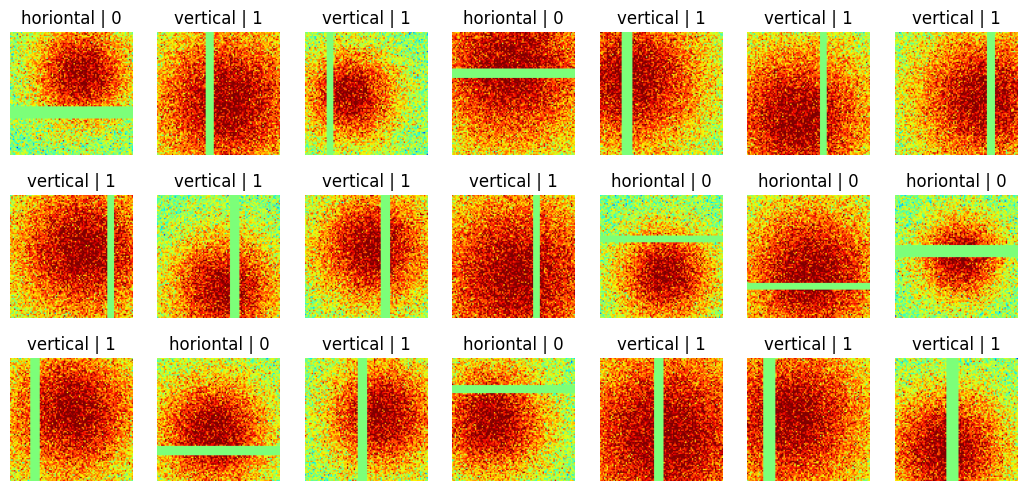

In [4]:
fig, axs = plt.subplots(3, 7, figsize = (13, 6))

for i, ax in enumerate(axs.flatten()):
  rand_row = np.random.randint(images.shape[0])
  ax.imshow(images[rand_row].squeeze(), vmin = -1, vmax = 1, cmap = 'jet')
  ax.axis('off')
  ax.set_xticks([])
  ax.set_yticks([])
  if labels[rand_row]:
    ori = 'vertical'
  else:
    ori = 'horiontal'
  ax.set_title(f'{ori} | {int(labels[rand_row])}')

plt.show()

# Loaders

In [5]:
labels = labels.view(-1, 1).float()

In [6]:
train_data, test_data, train_labels, test_labels = train_test_split(images, labels, test_size = .2)

train_dataset = TensorDataset(train_data, train_labels)
test_dataset = TensorDataset(test_data, test_labels)

batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
test_dataloader = DataLoader(test_dataset, batch_size = test_data.shape[0], shuffle = False)

# Model

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def CreateModel(verbose=False):

  class Net(nn.Module):
    def __init__(self):
      super().__init__()

      def block(cin, cout):
        return nn.Sequential(
          nn.Conv2d(cin, cout, 3, padding=1, bias=False),
          nn.BatchNorm2d(cout),
          nn.ReLU(inplace=True),
          nn.Conv2d(cout, cout, 3, padding=1, bias=False),
          nn.BatchNorm2d(cout),
          nn.ReLU(inplace=True),
        )

      self.b1 = block(1, 64)     # 32x32
      self.b2 = block(64, 128)   # 16x16
      self.b3 = block(128, 256)  # 8x8

      self.pool = nn.MaxPool2d(2)
      self.drop = nn.Dropout(0.3)
      self.gap  = nn.AdaptiveAvgPool2d(1)  # -> (B, C, 1, 1)
      self.fc   = nn.Linear(256, 1)

    def forward(self, x):
      x = self.pool(self.b1(x))
      if verbose: print("b1:", list(x.shape))  # (B,64,16,16)

      x = self.pool(self.b2(x))
      if verbose: print("b2:", list(x.shape))  # (B,128,8,8)

      x = self.pool(self.b3(x))
      if verbose: print("b3:", list(x.shape))  # (B,256,4,4)

      x = self.gap(x).squeeze(-1).squeeze(-1)
      x = self.drop(x)
      if verbose: print("gap:", list(x.shape))

      x = self.fc(x)
      if verbose: print("out:", list(x.shape))
      return x

  net = Net()
  optimizer = torch.optim.AdamW(net.parameters(), lr=3e-4, weight_decay=5e-4)
  loss_fn = nn.BCEWithLogitsLoss()
  return net, loss_fn, optimizer


In [9]:
net, loss_fn, optimizer = CreateModel()
X, y = next(iter(train_dataloader))
y_hat = net(X)
loss = loss_fn(y_hat, y)
loss

tensor(0.7367, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

In [14]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device

'cuda:0'

In [15]:
summary(net.to(device), (1, img_size, img_size))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 30, 30]             576
       BatchNorm2d-2           [-1, 64, 30, 30]             128
              ReLU-3           [-1, 64, 30, 30]               0
            Conv2d-4           [-1, 64, 30, 30]          36,864
       BatchNorm2d-5           [-1, 64, 30, 30]             128
              ReLU-6           [-1, 64, 30, 30]               0
         MaxPool2d-7           [-1, 64, 15, 15]               0
            Conv2d-8          [-1, 128, 15, 15]          73,728
       BatchNorm2d-9          [-1, 128, 15, 15]             256
             ReLU-10          [-1, 128, 15, 15]               0
           Conv2d-11          [-1, 128, 15, 15]         147,456
      BatchNorm2d-12          [-1, 128, 15, 15]             256
             ReLU-13          [-1, 128, 15, 15]               0
        MaxPool2d-14            [-1, 12

# Train

In [21]:
def RunModel():
  # number of epochs
  epochs = 3

  # create a new model
  net, loss_fn, optimizer = CreateModel()

  # initialize losses
  train_losses = torch.zeros(epochs)
  test_losses = torch.zeros(epochs)
  train_accs = torch.zeros(epochs)
  test_accs = torch.zeros(epochs)

  for epoch in range(epochs):
    # loop over training data batches
    batch_losses = []
    batch_accs = []

    for X, y in train_dataloader:

      # forward pass and loss
      y_hat = net(X)
      loss = loss_fn(y_hat, y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc = ((y_hat > 0).float() == y).float().mean().item()

      # batch loss and acc
      batch_losses.append(loss.item())
      batch_accs.append(batch_acc)

    # losses
    train_losses[epoch] = np.mean(batch_losses)
    train_accs[epoch] = 100 * np.mean(batch_accs)

    # test acc
    X, y = next(iter(test_dataloader))
    with torch.no_grad():
      y_hat = net(X)
      loss = loss_fn(y_hat, y)

    test_losses[epoch] = loss.item()
    test_acc = 100 * ((y_hat > 0).float() == y).float().mean().item()
    test_accs[epoch] = test_acc

    print(f'Epoch {epoch} Train Loss: {train_losses[epoch]:.4f}, Test Loss: {test_losses[epoch]:.4f}, Train Acc: {train_accs[epoch]:.4f}, Test Acc: {test_accs[epoch]:.4f}')

  return train_losses, test_losses, train_accs, test_accs, net

In [22]:
train_losses, test_losses, train_accs, test_accs, net = RunModel()

Epoch 0 Train Loss: 0.1668, Test Loss: 0.0418, Train Acc: 94.7500, Test Acc: 100.0000
Epoch 1 Train Loss: 0.0295, Test Loss: 0.0197, Train Acc: 100.0000, Test Acc: 100.0000
Epoch 2 Train Loss: 0.0179, Test Loss: 0.0127, Train Acc: 100.0000, Test Acc: 100.0000


# Test Images

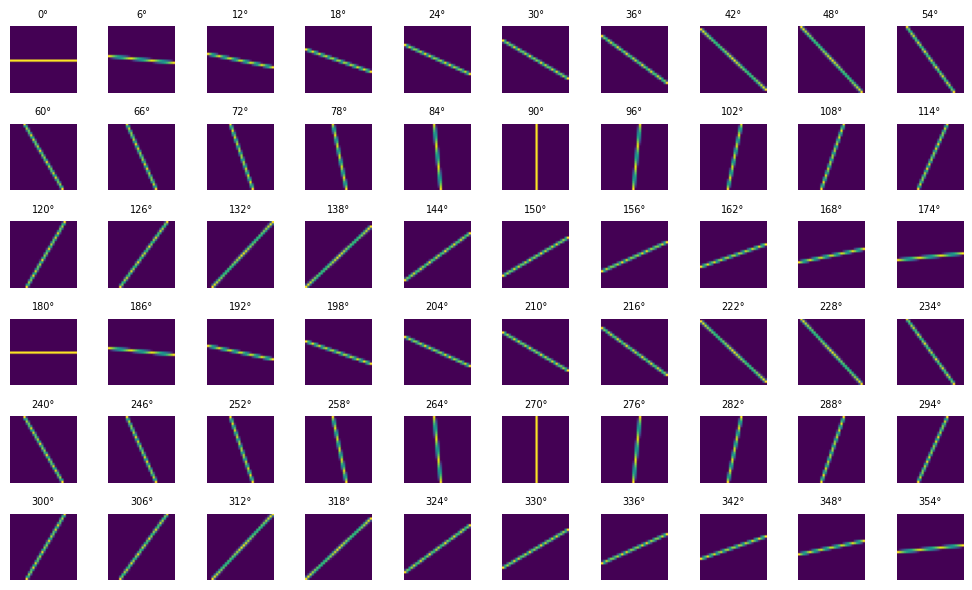

In [33]:
from skimage.draw import line_aa
import numpy as np
import matplotlib.pyplot as plt
import torch

img_size = 30
cx = cy = img_size // 2

angles = np.linspace(0, 2*np.pi, 60, endpoint=False)
rows, cols = 6, 10

test_imgs = torch.zeros((60, 1, img_size, img_size), dtype=torch.float32)

fig, axes = plt.subplots(rows, cols, figsize=(cols, rows))
axes = axes.flatten()

for i, theta in enumerate(angles):
    img = np.zeros((img_size, img_size), dtype=np.uint8)

    dx = np.cos(theta)
    dy = np.sin(theta)

    points = []

    if abs(dx) > 1e-6:
        for x_edge in [0, img_size-1]:
            t = (x_edge - cx) / dx
            y = cy + t * dy
            if 0 <= y < img_size:
                points.append((int(round(y)), int(round(x_edge))))

    if abs(dy) > 1e-6:
        for y_edge in [0, img_size-1]:
            t = (y_edge - cy) / dy
            x = cx + t * dx
            if 0 <= x < img_size:
                points.append((int(round(y_edge)), int(round(x))))

    max_d = -1
    for a in range(len(points)):
        for b in range(a+1, len(points)):
            d = (points[a][0]-points[b][0])**2 + (points[a][1]-points[b][1])**2
            if d > max_d:
                max_d = d
                (y0, x0), (y1, x1) = points[a], points[b]

    rr, cc, val = line_aa(y0, x0, y1, x1)
    valid = (rr >= 0) & (rr < img_size) & (cc >= 0) & (cc < img_size)
    img[rr[valid], cc[valid]] = (val[valid] * 255).astype(np.uint8)

    test_imgs[i, 0] = torch.from_numpy(img).float() / 255.0

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"{i*6}°", fontsize=7)

plt.tight_layout()
plt.show()

# Predictions

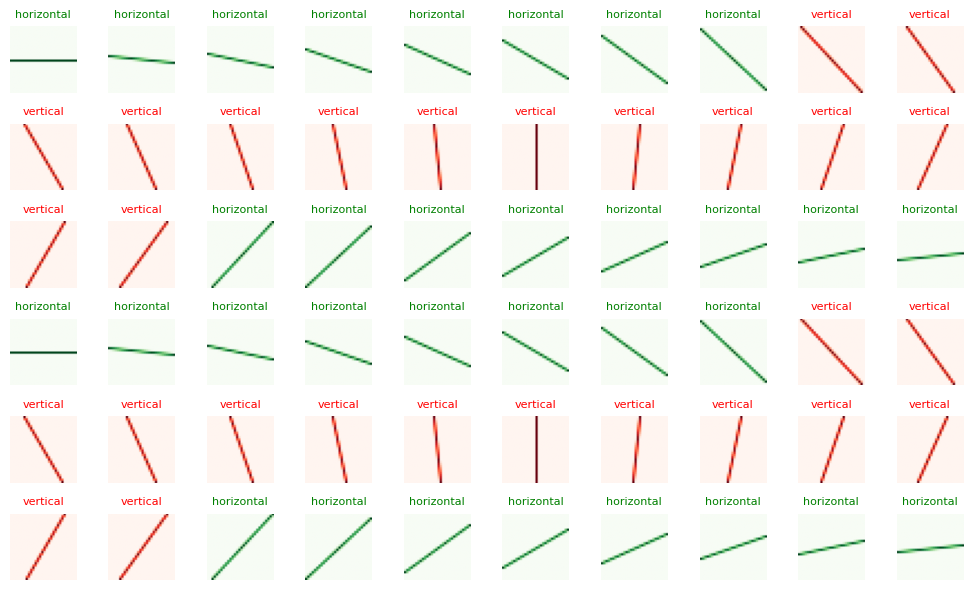

In [43]:
net.eval()

with torch.no_grad():
    logits = net(test_imgs)               # (60,1)
    preds = (logits > 0).int().squeeze()  # 1=vert, 0=hori

fig, axes = plt.subplots(6, 10, figsize=(10, 6))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = test_imgs[i, 0].cpu().numpy()

    if preds[i] == 1:
        cmap = "Reds"
        title = "vertical"
        color = "red"
    else:
        cmap = "Greens"
        title = "horizontal"
        color = "green"

    ax.imshow(img, cmap=cmap, vmin=0, vmax=1)
    ax.set_title(title, color=color, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Probability of Vertical

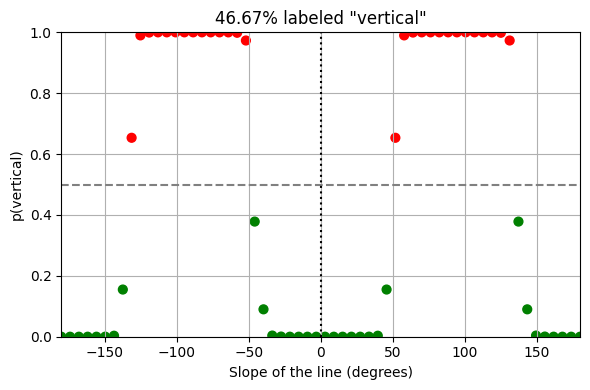

In [59]:
net.eval()
with torch.no_grad():
    yHat = torch.sigmoid(net(test_imgs)).squeeze().cpu().numpy()

# kąty od -180 do 180
angles_deg = np.linspace(-180, 180, len(yHat))

# sort
idx = np.argsort(angles_deg)
angles_deg = angles_deg[idx]
yHat = yHat[idx]

plt.figure(figsize=(6,4))

# plt.plot(angles_deg, yHat, 'k-', lw=2)
plt.scatter(
    angles_deg,
    yHat,
    c=np.where(yHat > 0.5, 'r', 'g'),
    s=40
)

plt.axhline(0.5, color='gray', ls='--')
plt.axvline(0, color='black', ls=':')

plt.xlabel('Slope of the line (degrees)')
plt.ylabel('p(vertical)')
plt.title(f'{(yHat>0.5).mean()*100:.2f}% labeled "vertical"')

plt.ylim(0, 1)
plt.xlim(-180, 180)
plt.grid(True)
plt.tight_layout()
plt.show()
